In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score,precision_score,recall_score,roc_auc_score
import joblib
import streamlit as st

In [4]:
df = pd.read_csv("cs-training.csv")

In [5]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
df.shape

(150000, 12)

In [7]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [8]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [11]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [12]:
print("Duplicated:- ",df.duplicated().sum())

Duplicated:-  609


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
print(df["SeriousDlqin2yrs"].value_counts())

SeriousDlqin2yrs
0    139382
1     10009
Name: count, dtype: int64


In [15]:
print(df["SeriousDlqin2yrs"].value_counts(normalize=True)*100)

SeriousDlqin2yrs
0    93.300132
1     6.699868
Name: proportion, dtype: float64


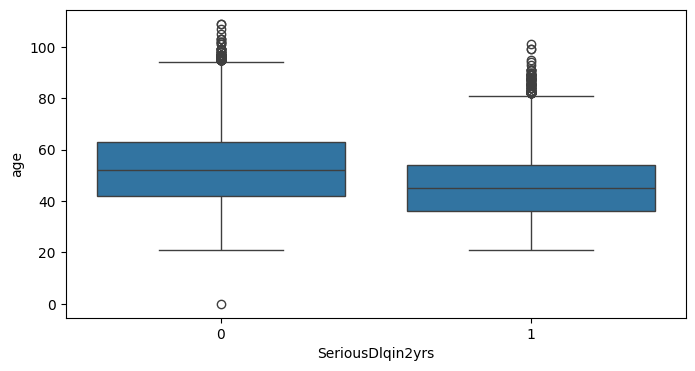

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(x="SeriousDlqin2yrs",y="age",data=df)
plt.show()

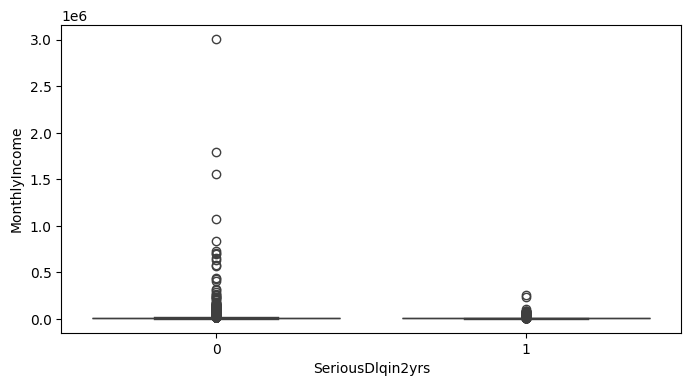

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(x="SeriousDlqin2yrs",y="MonthlyIncome",data=df)
plt.show()

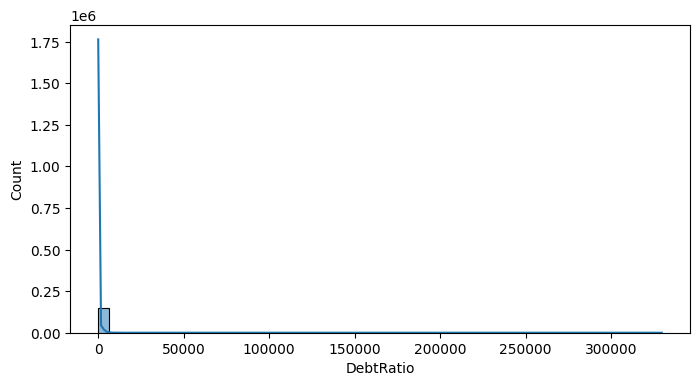

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(df["DebtRatio"],bins=50,kde=True)
plt.show()

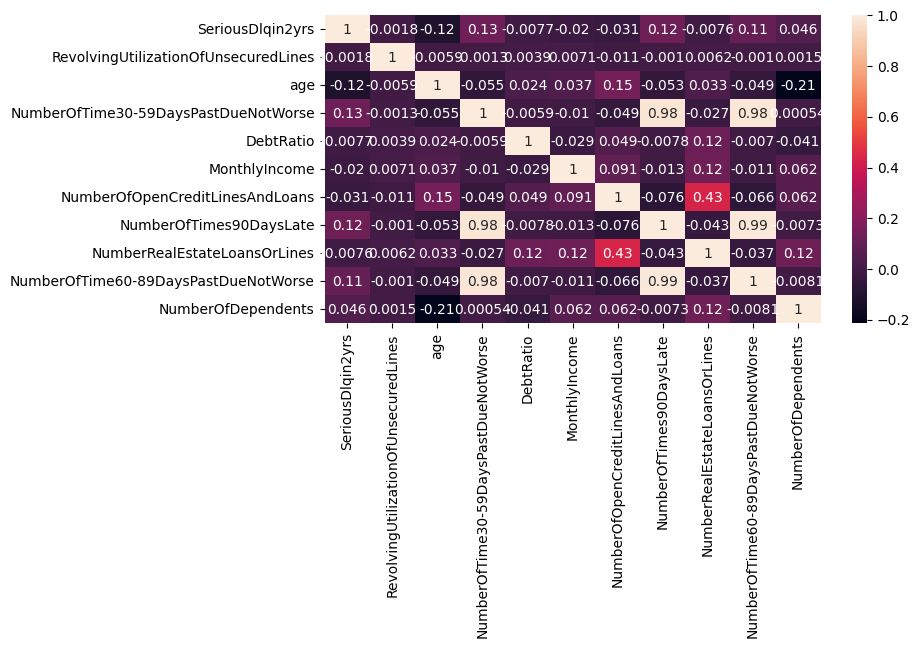

In [19]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [20]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=((df[col]<lower)|(df[col]>upper)).sum()
    percentage=round(outliers/len(df)*100,2)
    print(f"{col}:{outliers} ({percentage}%)")

SeriousDlqin2yrs:10009 (6.7%)
RevolvingUtilizationOfUnsecuredLines:769 (0.51%)
age:45 (0.03%)
NumberOfTime30-59DaysPastDueNotWorse:23938 (16.02%)
DebtRatio:31285 (20.94%)
MonthlyIncome:4878 (3.27%)
NumberOfOpenCreditLinesAndLoans:3980 (2.66%)
NumberOfTimes90DaysLate:8283 (5.54%)
NumberRealEstateLoansOrLines:793 (0.53%)
NumberOfTime60-89DaysPastDueNotWorse:7560 (5.06%)
NumberOfDependents:13336 (8.93%)


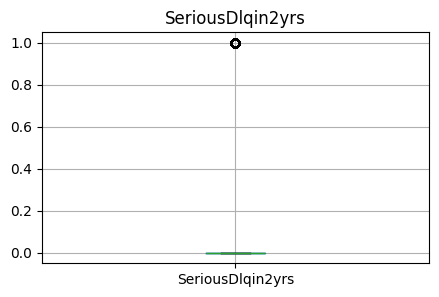

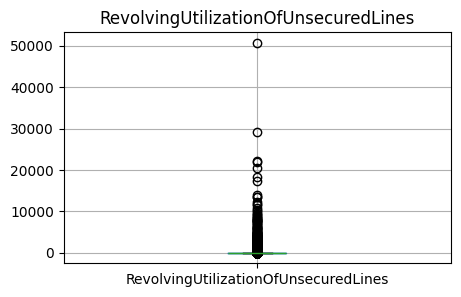

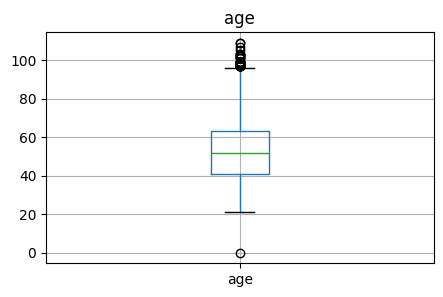

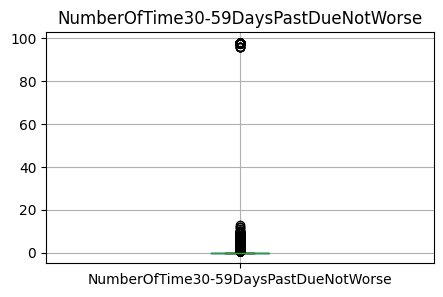

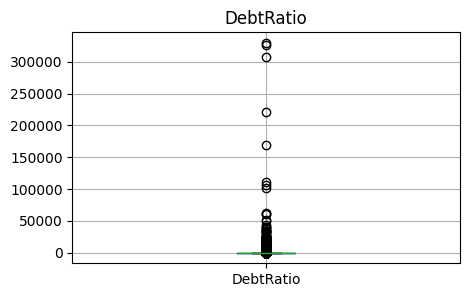

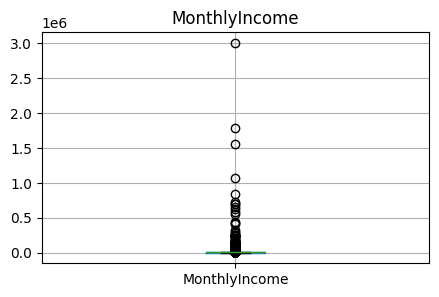

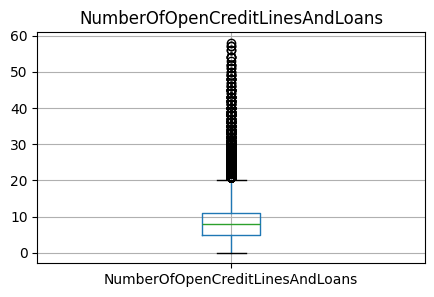

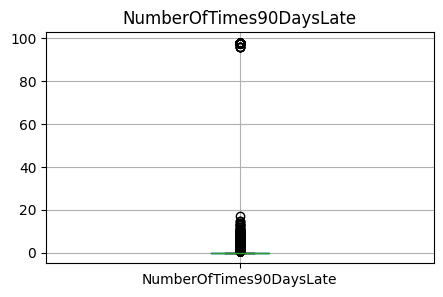

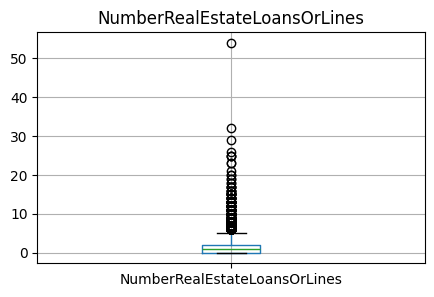

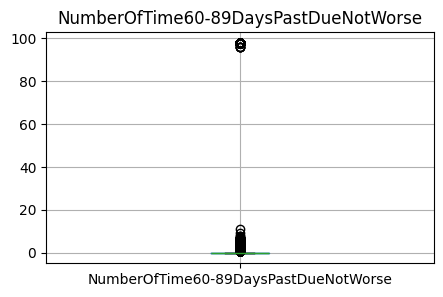

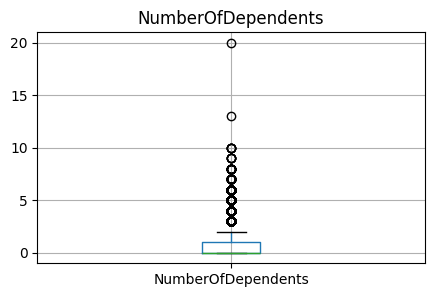

In [21]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    df.boxplot(column=col)
    plt.title(col)
    plt.show()

In [22]:
x=df.drop("SeriousDlqin2yrs",axis=1)
y=df["SeriousDlqin2yrs"]

In [23]:
number_cols=x.select_dtypes(include=["int64","float64"]).columns.tolist()
print(number_cols)

['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [24]:
number_pipeline=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",RobustScaler())
])

In [25]:
preprocessor=ColumnTransformer(transformers=[
    ("num",number_pipeline,number_cols)
])

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [27]:
model_lr = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=42)),
    ("model",LogisticRegression(max_iter=1000,class_weight="balanced"))
])

In [28]:
model_lr.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['RevolvingUtilizationOfUnsecuredLines',
                                                   'age',
                                                   'NumberOfTime30-59DaysPastDueNotWorse',
                                                   'DebtRatio', 'MonthlyIncome',
                                                   'NumberOfOpenCreditLinesAndLoans',
                                                   'NumberOfTimes90DaysLate',
                                                   'NumberRealEstateLoansOrLines',
                                                   'NumberOfTime60-89DaysPastDueNotWorse',
                                                   'NumberOfDependents'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [29]:
y_pred = model_lr.predict(x_test)
y_prob=model_lr.predict_proba(x_test)[:1]

In [30]:
print("Accuracy score:- ",accuracy_score(y_test,y_pred))
print("precision_score:- ",precision_score(y_test,y_pred))
print("Recall score:- ",recall_score(y_test,y_pred))
print("F1 score:- ",f1_score(y_test,y_pred))
lr_auc=roc_auc_score(y_test,y_pred)
print("Roc AUc:- ",lr_auc)

Accuracy score:-  0.7818869440074969
precision_score:-  0.18519035002091758
Recall score:-  0.6633366633366633
F1 score:-  0.289545404992914
Roc AUc:-  0.7268686760382423


In [31]:
model_rf=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=42)),
    ("model",RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1))
])

In [32]:
model_rf.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['RevolvingUtilizationOfUnsecuredLines',
                                                   'age',
                                                   'NumberOfTime30-59DaysPastDueNotWorse',
                                                   'DebtRatio', 'MonthlyIncome',
                                                   'NumberOfOpenCreditLinesAndLoans',
                                                   'NumberOfTimes90DaysLate',
                                                   'NumberRealEstateLoansOrLines',
                                                   'NumberOfTime60-89DaysPastDueNotWorse',
                                                   'NumberOfDependents'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [33]:
y_pred_1=model_rf.predict(x_test)
y_prob=model_rf.predict_proba(x_test)[:,1]

In [34]:
print("Accuracy:- ",accuracy_score(y_test,y_pred_1))
print("Precision:- ",precision_score(y_test,y_pred_1))
print("Recall:- ",recall_score(y_test,y_pred_1))
print("F1_score:- ",f1_score(y_test,y_pred_1))
rf_auc=roc_auc_score(y_test,y_pred_1)
print("ROC AUC:- ",rf_auc)

Accuracy:-  0.9151578031393286
Precision:-  0.3719365689572321
Recall:-  0.3866133866133866
F1_score:-  0.37913299044819987
ROC AUC:-  0.6698644290745306


In [35]:
model_gb=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=42)),
    ("model",GradientBoostingClassifier(n_estimators=200,random_state=42))
])

In [36]:
model_gb.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['RevolvingUtilizationOfUnsecuredLines',
                                                   'age',
                                                   'NumberOfTime30-59DaysPastDueNotWorse',
                                                   'DebtRatio', 'MonthlyIncome',
                                                   'NumberOfOpenCreditLinesAndLoans',
                                                   'NumberOfTimes90DaysLate',
                                                   'NumberRealEstateLoansOrLines',
                                                   'NumberOfTime60-89DaysPastDueNotWorse',
                                                   'NumberOfDependents'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])

In [37]:
y_pred_2=model_gb.predict(x_test)
y_prob=model_gb.predict_proba(x_test)[:,1]

In [38]:
print("Accuracy score:- ",accuracy_score(y_test,y_pred_2))
print("precision score:- ",precision_score(y_test,y_pred_2))
print("Recall score:- ",recall_score(y_test,y_pred_2))
print("F1_score:- ",f1_score(y_test,y_pred_2))
gb_auc=roc_auc_score(y_test,y_pred_2)
print("ROC ACU:-",gb_auc)

Accuracy score:-  0.9108069212490378
precision score:-  0.3730371505170433
Recall score:-  0.4865134865134865
F1_score:-  0.42228484717103837
ROC ACU:- 0.7138956211847843


In [39]:
model_xgb=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=42)),
    ("model",XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,random_state=42))
])

In [40]:
model_xgb.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['RevolvingUtilizationOfUnsecuredLines',
                                                   'age',
                                                   'NumberOfTime30-59DaysPastDueNotWorse',
                                                   'DebtRatio', 'MonthlyIncome',
                                                   'NumberOfOpenCreditLinesAndLoans',
                                                   'NumberOfTimes90DaysLate',
                                                   'NumberRealEstate...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [41]:
y_pred_3=model_xgb.predict(x_test)
xgb_prob=model_xgb.predict_proba(x_test)[:,1]

In [42]:
print("Accuracy score->  ",accuracy_score(y_test,y_pred_3))
print("Recall score-> ",recall_score(y_test,y_pred_3))
print("Precision score-> ",precision_score(y_test,y_pred_3))
print("f1 score ->",f1_score(y_test,y_pred_3))
xgb_auc=roc_auc_score(y_test,y_pred_3)
print("ROC AUC-> ",xgb_auc)

Accuracy score->   0.9193748117406875
Recall score->  0.43506493506493504
Precision score->  0.40530479292694277
f1 score -> 0.41965791375572153
ROC AUC->  0.6946103453528929


In [43]:
results=pd.DataFrame({
    "Model":["Logistic Regression","Rendom Forest","Gradient Boosting","XGBoost"],
    "ROC_AUC":[lr_auc,rf_auc,gb_auc,xgb_auc]
})
results.sort_values(by="ROC_AUC",ascending=False)

,Model,ROC_AUC
0,Logistic Regression,0.726869
2,Gradient Boosting,0.713896
3,XGBoost,0.694610
1,Rendom Forest,0.669864


In [44]:
joblib.dump(model_lr,"credit_deafult_model.joblib")

['credit_deafult_model.joblib']

In [45]:
%%writefile app2.py
import pandas as pd
import joblib
import streamlit as st
model=joblib.load("credit_deafult_model.joblib")
st.title("Credit Default Risk Prediction")
st.write("Enter customer details")
RevolvingUtilizationOfUnsecuredLines =st.number_input("Revolving Utilization Of Unsecured Lines ",min_value=0.0)
age=st.number_input("Age ",min_value=18)
NumberOfTime30_59DaysPastDueNotWorse=st.number_input("Number Of Time 30-59 Days Past Due Not Worse",min_value=0)
DebtRatio=st.number_input("Debt Ration",min_value=0.0)
MonthlyIncome=st.number_input("Monthly Income",min_value=0.0)
NumberOfOpenCreditLinesAndLoans=st.number_input("Number Of Open Credit Lines And Loans",min_value=0.0)
NumberOfTimes90DaysLate=st.number_input("Number Of Times 90 Days Late",min_value=0)
NumberRealEstateLoansOrLines=st.number_input("Number Real Estate Loans Or Lines",min_value=0.0)
NumberOfTime60_89DaysPastDueNotWorse=st.number_input("Number Of Time 60-89 Days Past Due Not Worse",min_value=0.0)
NumberOfDependents=st.number_input("Number Of Dependents",min_value=0.0)
if st.button("Predict"):
    input_df=pd.DataFrame({"RevolvingUtilizationOfUnsecuredLines":[RevolvingUtilizationOfUnsecuredLines],
                          "age":[age],
                          "NumberOfTime30-59DaysPastDueNotWorse":[NumberOfTime30_59DaysPastDueNotWorse],
                          "DebtRatio":[DebtRatio],
                          "MonthlyIncome":[MonthlyIncome],
                          "NumberOfOpenCreditLinesAndLoans":[NumberOfOpenCreditLinesAndLoans],
                          "NumberOfTimes90DaysLate":[NumberOfTimes90DaysLate],
                          "NumberRealEstateLoansOrLines":[NumberRealEstateLoansOrLines],
                           "NumberOfTime60-89DaysPastDueNotWorse":[NumberOfTime60_89DaysPastDueNotWorse],
                           "NumberOfDependents":[NumberOfDependents]
                           
                          })
    prediction=model.predict(input_df)[0]
    probability=model.predict_proba(input_df)[0][1]
    if prediction==1:
        st.error("High Risk Of Default")
    else:
        st.success("Low Risk of Default")
    st.write(f"Default Probability:{probability: .2%}")









Overwriting app2.py


In [46]:
%%writefile requirements.txt
streamlit
pandas
numpy
sckit-learn
imbalanced-learn
joblib

Overwriting requirements.txt


In [47]:
%%writefile README.md

# Credit Default Risk Prediction

## 📌 Project Overview
This project predicts whether a customer will default on a loan using Machine Learning.

## 📊 Dataset
- Credit / Loan dataset (from Kaggle or custom data)

## ⚙️ Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib / Seaborn

## 🧠 Machine Learning Model
- Logistic Regression / Random Forest / XGBoost

## 📈 Workflow
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Training
5. Model Evaluation

## 🎯 Goal
To help banks predict risky customers and reduce financial loss.

## 🚀 How to Run
1. Clone repository
2. Install requirements
3. Run Jupyter notebook

## 👨‍💻 Author
Harshit Sharma

Overwriting README.md
